In [1]:
import numpy as np
import matplotlib.pyplot as plt

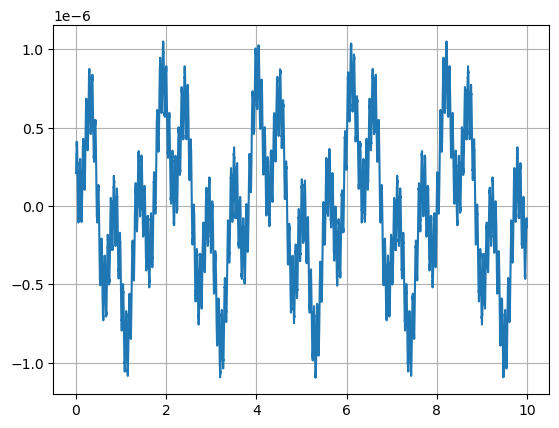

In [2]:
# define a simple 1 DoF system
amps = np.array([0.5,0.4,0.02,0.2])*1e-6
freqs = np.array([3,12,740,92])
phases = np.array([0,125,69,250])

dt = 1e-4
tvec = np.arange(1e+5)*dt

plant = lambda t: amps[0]*np.cos(t*freqs[0]+phases[0]/180*np.pi) + amps[1]*np.cos(t*freqs[1]+phases[1]/180*np.pi) + amps[2]*np.cos(t*freqs[2]+phases[2]/180*np.pi) + amps[3]*np.cos(t*freqs[3]+phases[3]/180*np.pi)
y = plant(tvec)

plt.figure()
plt.plot(tvec,y)
plt.grid()

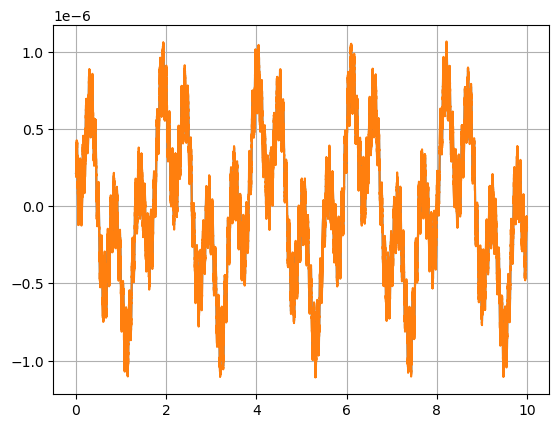

In [3]:
# simple controller with noise and n-steps delay
sigma = 1e-8
y_meas = y + np.random.randn(len(y))*sigma

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,y_meas)
plt.grid()

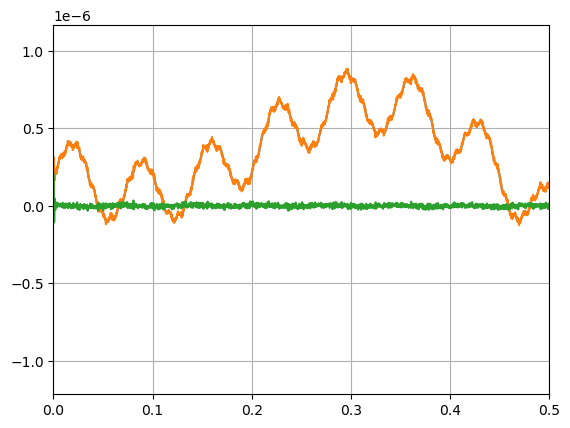

In [4]:
# actuator with n steps delay
N = len(y)
cmd_hist = np.zeros(N)
cmd = 0
int_gain = 0.4
delay_steps = 3

for j in range(N):
    if j >= delay_steps:
        meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn(1)*sigma
    else:
        meas = y[j] + np.random.randn(1)*sigma
    cmd += int_gain*meas[0]
    cmd_hist[j] = cmd

res = y.copy()
res[delay_steps:] -= cmd_hist[:-delay_steps]

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,cmd_hist)
plt.plot(tvec,res)
plt.xlim([0,0.5])
plt.grid()

In [35]:
# Predictor controller, M = 1, N = 4
Mf = 3 # future steps
Np = 4 # past states
theta = np.zeros([Mf,2*Np + Mf]) # parameters
P = np.eye(2*Np+Mf)*1e+14

gamma = 1.0 # forgetting factor
lreg = 1e-3

In [36]:

CMAT = lambda A,B,C,lreg: -np.linalg.pinv(C.T @ C + lreg*np.eye(len(C))) @ np.vstack([A.T @ C, B.T @ C]).T

In [37]:
def ddspc_update(target, phi_train, theta, P, gamma=0.999):
    """
    Updates the system identification model using RLS.
    target: The Mf sequence of actual observations (deltas) that just occurred.
    phi_train: The feature vector recorded Mf steps ago.
    """
    K = P @ phi_train / (gamma + phi_train.T @ P @ phi_train)
    err = target - theta @ phi_train[:, 0]
    theta += np.outer(err, K.T)
    P = 1/gamma * (P - K @ phi_train.T @ P)
    return theta, P

def ddspc_control(phi_current, theta, Np, lreg=1e-3):
    """
    Computes the optimal future commands using the updated model and current features.
    """
    A = theta[:, :Np]
    B = theta[:, Np:2*Np]
    C = theta[:, 2*Np:]
    # Assuming CMAT is defined elsewhere in your notebook as in the original code
    Cmat = CMAT(A, B, C, lreg) 
    cmds = Cmat @ phi_current[:2*Np]
    return cmds[:, 0]

In [44]:
# --- Main Simulation Loop ---
# Initialize buffers
past_y = np.zeros(Np)  # FIX 3: Will now store delta y
past_u = np.zeros(Np)  # FIX 3: Will now store delta u
future_u = np.zeros(Mf)
cmd_hist = np.zeros(len(y))

# Buffers for time alignment (delaying phi)
phi_hist = []
delta_y_hist = []

# Variables to calculate deltas
y_meas_prev = 0
cmd_prev = 0
cmd = 0

# Parameters
sigma = 0
bootstrap = 200
n = 4
gamma = 0.999

for j in range(n * bootstrap):
    
    # 1. Observe the system
    if j >= delay_steps:
        y_meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn()*sigma
    else:
        y_meas = y[j] + np.random.randn()*sigma
        
    # FIX 3: Work with deltas to retain integral action
    delta_y = y_meas - y_meas_prev
    delta_y_hist.append(delta_y)
    
    # 2. System Identification (RLS Update)
    # FIX 1 & FIX 2: Use dynamic targets and correct time alignment
    # We update theta only when we have the actual Mf future targets for a previously recorded phi
    if len(delta_y_hist) >= Mf and len(phi_hist) >= Mf:
        # Target is the actual sequence of the last Mf delta_y measurements
        target_meas = np.array(delta_y_hist[-Mf:])
        # The corresponding features from Mf steps ago
        phi_train = phi_hist[-Mf]
        
        theta, P = ddspc_update(target_meas, phi_train, theta, P, gamma)
        
    # 3. Control Computation
    # FIX 3: Construct current feature vector using past deltas
    phi_current = np.concatenate([past_y, past_u, future_u]).reshape([2*Np+Mf, 1])
    
    if j > bootstrap:
        # DDSPC Control
        future_cmds = ddspc_control(phi_current, theta, Np)
        delta_cmd = future_cmds[0]
        cmd = cmd_prev + delta_cmd
        future_u = future_cmds  # Update assumed future commands for the next step's phi
    else:
        # Bootstrap phase: Integrator
        cmd = cmd_prev + int_gain * y_meas
        delta_cmd = cmd - cmd_prev
        future_u = np.ones(Mf) * delta_cmd  # Naive guess for future steps during bootstrap
        
    cmd_hist[j] = cmd
    
    # Store phi_current for future training
    phi_hist.append(phi_current)
    
    # Update past delta buffers
    past_y = np.roll(past_y, -1)
    past_y[-1] = delta_y
    past_u = np.roll(past_u, -1)
    past_u[-1] = delta_cmd
    
    # Store absolute values for next step's delta calculation
    y_meas_prev = y_meas
    cmd_prev = cmd

In [45]:
print(theta)

[[-1.76628689e-05 -2.76694506e-05 -3.97441398e-05  1.22885033e-01
   1.22932637e-01  3.74702049e-05 -9.99968851e-01  8.44029706e-06
   8.44029723e-06  5.61387631e-07  3.14658917e-07]
 [-1.68848896e-05 -2.68663714e-05 -3.90107838e-05  1.22223505e-01
   1.22270447e-01  3.74306516e-05  3.13734420e-05 -4.99991508e-01
  -4.99991508e-01  5.32777733e-07  2.95552992e-07]
 [-1.53492143e-01  4.69287011e-01  6.23158815e-01 -4.33708223e+00
  -4.53073152e+00 -6.77805265e-02  2.11239790e-01  5.09173531e-01
   5.09173530e-01  2.10165052e-02  1.61926796e-02]]


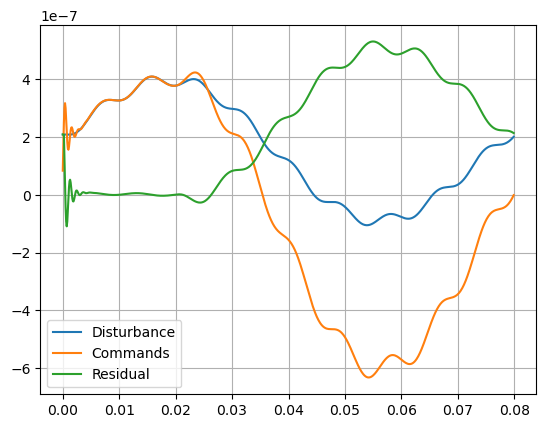

In [46]:
res = y.copy()
res[delay_steps:n*bootstrap] -= cmd_hist[:n*bootstrap-delay_steps]

plt.figure()
plt.plot(tvec[:n*bootstrap],y[:n*bootstrap], label='Disturbance')
plt.plot(tvec[:n*bootstrap],cmd_hist[:n*bootstrap], label='Commands')
plt.plot(tvec[:n*bootstrap],res[:n*bootstrap], label='Residual')
# plt.xlim([0,0.5])
plt.legend()
plt.grid()